# nb23 - Truth-timing upper-bound: is sigma_eff = 0.03 physically reachable?

nb21's upper-bound used a *seed-relative* (data-driven) in-time cut and barely moved. But the dataset carries **`sig_flux_timing`** - the true photon arrival time, which pileup cannot shift. This lets us reject out-of-time pileup with **truth**: a cell is signal-like if its measured time matches the photon time (plus a fixed readout offset). If the calibrated sum over a large window of truth-in-time cells reaches ~0.03, the information for 0.03 exists and a model can chase it; if even this floors well above 0.03, 0.03 is not reachable from these cell inputs and needs a different representation (e.g. 2D shower image, or recovering timing for the ~69% untimed cells).

In [1]:
import sys, pathlib, os
import numpy as np, pandas as pd, uproot, awkward as ak, matplotlib.pyplot as plt
REPO = pathlib.Path(os.environ['REPO_DIR']) if os.environ.get('REPO_DIR') else (
    pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd())
sys.path.insert(0, str(REPO / 'scripts'))
from run_experiments import split, resolution, CELL_KEYS, EPS
FIG = REPO / 'reports' / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
FILES = sorted((REPO / 'data' / 'minimum_bias').glob('matched_*.root'))
print(len(FILES), 'files')

94 files


## Load: per cluster keep energies, dist-to-seed, front time, and the truth photon time

In [2]:
TK = CELL_KEYS + ['cell_times_front']
AUX = ['sig_flux_prod_vertex_z', 'sig_flux_eTot', 'sig_flux_timing']
def load(files):
    E, R, T, Et, ST = [], [], [], [], []
    for path in files:
        with uproot.open(path) as f:
            a = f['clusters_matched'].arrays(TK + AUX, library='ak')
        vz = ak.to_numpy(a['sig_flux_prod_vertex_z']).astype(float)
        st = ak.to_numpy(a['sig_flux_timing']).astype(float)
        for i in np.flatnonzero(vz < 100.0):
            cc = {k: np.asarray(ak.to_numpy(a[k][i])).astype(float) for k in TK}
            e = cc['energy']
            if len(e) == 0: continue
            seed = int(np.argmax(e))
            rdr = np.hypot(cc['cell_x'] - cc['cell_x'][seed], cc['cell_y'] - cc['cell_y'][seed])
            o = np.argsort(rdr)
            E.append(e[o]); R.append(rdr[o]); T.append(cc['cell_times_front'][o])
            Et.append(float(a['sig_flux_eTot'][i])); ST.append(float(st[i]))
    return E, R, T, np.array(Et), np.array(ST)
E, R, T, Et, ST = load(FILES)
print('clusters', len(Et))

clusters 89797


## Fixed readout offset between cell time and truth photon time
For valid-timed cells, `cell_time - sig_flux_timing` should cluster at a constant (readout offset + tiny in-cluster TOF); the wide tail is pileup. Use the global mode/median as the offset, then a signal cell satisfies `|cell_time - sig_flux_timing - OFF| < tau`.

In [3]:
alld = []
for t, st in zip(T, ST):
    v = np.abs(t) < 1e6
    alld.append(t[v] - st)
alld = np.concatenate(alld)
OFF = float(np.median(alld))
print(f'offset median {OFF:.3f} ns | IQR/1.349 {np.subtract(*np.percentile(alld,[75,25]))/1.349:.3f} '
      f'| 5-95pct {np.percentile(alld,5):.2f}..{np.percentile(alld,95):.2f}')

offset median 43.232 ns | IQR/1.349 1.307 | 5-95pct 42.43..69.03


## Calibrated-sum sigma_eff for a per-cluster mask (train/test split)

In [4]:
keep = np.flatnonzero((Et >= 1.0) & (Et <= 100.0))
tr, va, te = (keep[s] for s in split(len(keep)))
def sig_eff(sums):
    s = np.asarray(sums)
    la, lb = np.polyfit(np.log(s[tr] + EPS), np.log(Et[tr]), 1)
    return resolution(np.exp(la * np.log(s[te] + EPS) + lb), Et[te])['sigma_eff']

## Truth-in-time sum: scan window N x time-cut tau, keep vs drop untimed cells

In [5]:
def masked_sum(N, tau, drop_untimed):
    out = []
    for e, t, st in zip(E, T, ST):
        n = min(N, len(e)); ee = e[:n]; tt = t[:n]
        timed = np.abs(tt) < 1e6
        intime = timed & (np.abs(tt - st - OFF) <= tau)
        m = intime if drop_untimed else (intime | ~timed)
        out.append(ee[m].sum())
    return np.array(out)
rows = []
for N in [25, 40, 60, 81, 120]:
    for tau in [np.inf, 2.0, 1.0, 0.5]:
        for du in [False, True]:
            s = sig_eff(masked_sum(N, tau, du))
            rows.append(dict(N=N, tau=tau, drop_untimed=du, sigma_eff=round(s, 4)))
    print(f'N={N} done', flush=True)
RES = pd.DataFrame(rows)
print(RES.pivot_table(index=['N'], columns=['drop_untimed', 'tau'], values='sigma_eff').to_string())
print('BEST truth-in-time sum sigma_eff:', RES['sigma_eff'].min(), '->',
      RES.loc[RES['sigma_eff'].idxmin()].to_dict())

N=25 done


N=40 done


N=60 done


N=81 done


N=120 done


drop_untimed   False                           True                         
tau              0.5     1.0     2.0     inf     0.5     1.0     2.0     inf
N                                                                           
25            0.5737  0.1995  0.1801  0.1837  0.5487  0.5801  0.5812  0.5823
40            0.5610  0.2404  0.2280  0.2322  0.5400  0.5801  0.5777  0.5658
60            0.5392  0.2740  0.2635  0.2673  0.5349  0.5635  0.5548  0.5244
81            0.5291  0.2961  0.2905  0.2938  0.5321  0.5404  0.5236  0.4691
120           0.5146  0.3238  0.3152  0.3166  0.5295  0.5018  0.4546  0.3377
BEST truth-in-time sum sigma_eff: 0.1801 -> {'N': 25, 'tau': 2.0, 'drop_untimed': False, 'sigma_eff': 0.1801}


## Verdict

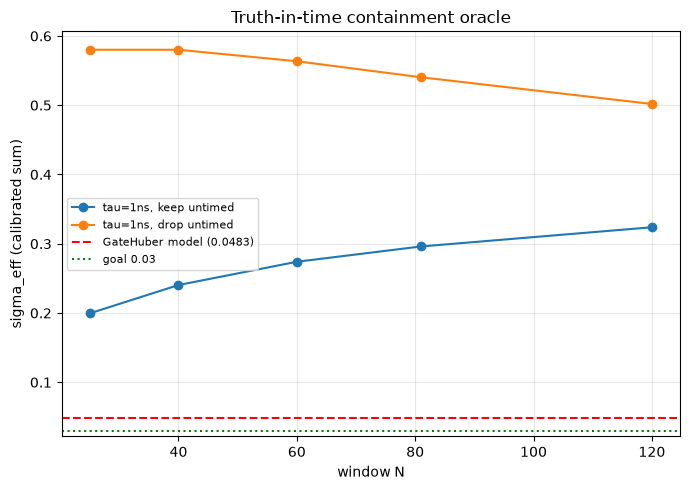

=> best truth-in-time sum 0.1801
=> even perfect (truth) pileup rejection floors at 0.180 > 0.03: need a different input representation


In [6]:
best = RES['sigma_eff'].min()
fig, ax = plt.subplots(figsize=(7, 5))
for du in [False, True]:
    sub = RES[(RES.drop_untimed == du) & (RES.tau == 1.0)].sort_values('N')
    ax.plot(sub['N'], sub['sigma_eff'], 'o-', label=f'tau=1ns, {"drop" if du else "keep"} untimed')
ax.axhline(0.0483, ls='--', color='r', label='GateHuber model (0.0483)')
ax.axhline(0.03, ls=':', color='g', label='goal 0.03')
ax.set_xlabel('window N'); ax.set_ylabel('sigma_eff (calibrated sum)')
ax.set_title('Truth-in-time containment oracle'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(FIG / 'fig8_truth_oracle.png', dpi=130); plt.show()
print('=> best truth-in-time sum', best)
print('=> 0.03 REACHABLE from these cells' if best <= 0.035 else
      '=> even perfect (truth) pileup rejection floors at %.3f > 0.03: need a different input representation' % best)